# Density estimation - Kernel density estimator

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity
from scipy.stats import norm

In [2]:
n = 200
n_component1 = int(0.1 * n)
n_component2 = n - n_component1

samples = np.concatenate([
    np.random.normal(loc=10, scale=1, size=n_component1),
    np.random.normal(loc=5, scale=1, size=n_component2),
])
np.random.shuffle(samples)

In [3]:
kde = KernelDensity(kernel='gaussian')
kde.fit(samples.reshape(-1, 1))

,"bandwidth bandwidth: float or {""scott"", ""silverman""}, default=1.0The bandwidth of the kernel. If bandwidth is a float, it defines thebandwidth of the kernel. If bandwidth is a string, one of the estimationmethods is implemented.",1.0
,"algorithm algorithm: {'kd_tree', 'ball_tree', 'auto'}, default='auto'The tree algorithm to use.",'auto'
,"kernel kernel: {'gaussian', 'tophat', 'epanechnikov', 'exponential', 'linear', 'cosine'}, default='gaussian'The kernel to use.",'gaussian'
,"metric metric: str, default='euclidean'Metric to use for distance computation. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.Not all metrics are valid with all algorithms: refer to thedocumentation of :class:`BallTree` and :class:`KDTree`. Note that thenormalization of the density output is correct only for the Euclideandistance metric.",'euclidean'
,"atol atol: float, default=0The desired absolute tolerance of the result. A larger tolerance willgenerally lead to faster execution.",0
,"rtol rtol: float, default=0The desired relative tolerance of the result. A larger tolerance willgenerally lead to faster execution.",0
,"breadth_first breadth_first: bool, default=TrueIf true (default), use a breadth-first approach to the problem.Otherwise use a depth-first approach.",True
,"leaf_size leaf_size: int, default=40Specify the leaf size of the underlying tree. See :class:`BallTree`or :class:`KDTree` for details.",40
,"metric_params metric_params: dict, default=NoneAdditional parameters to be passed to the tree for use with themetric. For more information, see the documentation of:class:`BallTree` or :class:`KDTree`.",None


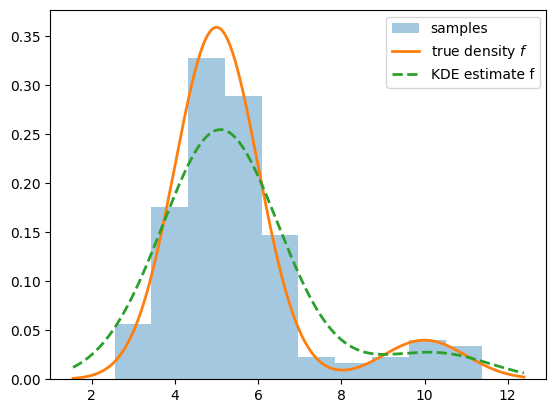

In [4]:
x = np.linspace(samples.min() - 1, samples.max() + 1, 500)

real_pdf = lambda x: 0.1 * norm.pdf(x, loc=10, scale=1) + 0.9 * norm.pdf(x, loc=5, scale=1)
f_true = real_pdf(x)

f_hat = np.exp(kde.score_samples(x.reshape(-1, 1)))

fig, ax = plt.subplots()
ax.hist(samples, density=True, alpha=0.4, label="samples")
ax.plot(x, f_true, label="true density $f$", linewidth=2)
ax.plot(x, f_hat, linestyle="--", label=r"KDE estimate f", linewidth=2)
ax.legend()
plt.show()

In [5]:
x = np.arange(2,13)

MSE = np.average((real_pdf(x) - np.exp(kde.score_samples(x.reshape(-1, 1))))**2)
print(MSE)

0.001651559525432087


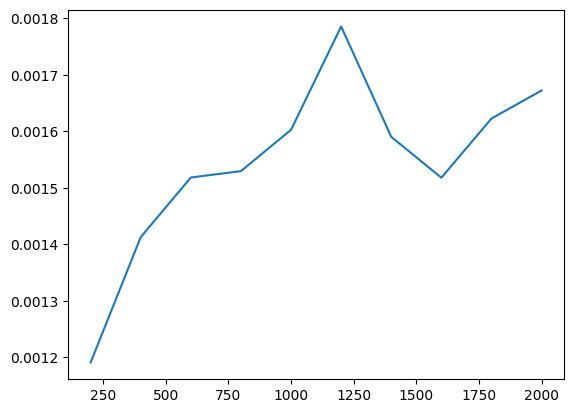

In [15]:
MSEs = []

for n in range(200, 2001, 200):
    # Generate samples
    n_component1 = int(0.1 * n)
    n_component2 = n - n_component1
    samples = np.concatenate([
        np.random.normal(loc=10, scale=1, size=n_component1),
        np.random.normal(loc=5, scale=1, size=n_component2),
    ])
    np.random.shuffle(samples)

    # Fit KDE
    kde = KernelDensity(kernel='gaussian')
    kde.fit(samples.reshape(-1, 1))

    # Get MSE score
    x = np.arange(2,13)

    MSE = np.average((real_pdf(x) - np.exp(kde.score_samples(x.reshape(-1, 1))))**2)
    MSEs.append(MSE)
plt.plot(list(range(200, 2001, 200)), MSEs)

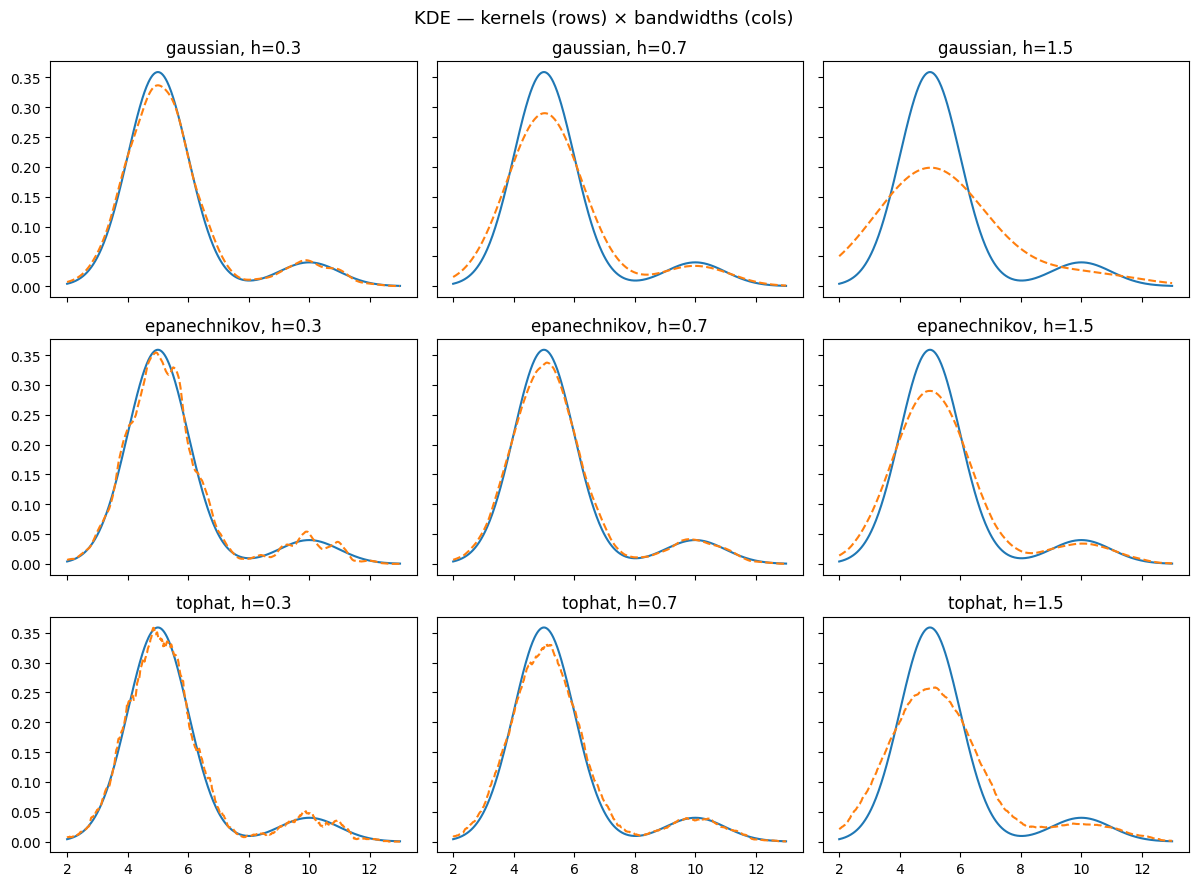

In [21]:
kernels = ['gaussian', 'epanechnikov', 'tophat']
bandwidths = [0.3, 0.7, 1.5]

x_plot = np.linspace(2, 13, 500)
f_true = real_pdf(x_plot)

fig, axes = plt.subplots(3, 3, figsize=(12, 9), sharex=True, sharey=True)
fig.suptitle("KDE — kernels (rows) × bandwidths (cols)", fontsize=13)

for i, kernel in enumerate(kernels):
    for j, bw in enumerate(bandwidths):
        ax = axes[i, j]

        kde_ = KernelDensity(kernel=kernel, bandwidth=bw)
        kde_.fit(samples.reshape(-1, 1))
        f_hat = np.exp(kde_.score_samples(x_plot.reshape(-1, 1)))

        ax.plot(x_plot, f_true, linewidth=1.5)
        ax.plot(x_plot, f_hat, linestyle="--", linewidth=1.5)
        ax.set_title(f"{kernel}, h={bw}")

plt.tight_layout()
plt.show()